In [1]:
import sys
sys.path.append('../')
import imageio
import matplotlib.pyplot as plt
import json
import os
from utils.paths import path_data_cholect50
from vid_inference.scenegraph_visualizer import SceneGraphVisualizer
from data.cataracts_scene_graph2 import CataractSceneGraphDataset
from copy import deepcopy
from IPython.display import SVG, display

In [2]:
sg_visualizer = SceneGraphVisualizer(CataractSceneGraphDataset.SEG_LABELS.keys())

In [3]:
video_idx = 5
video = imageio.get_reader(f"/local/scratch/Catarakt/videos/micro/train{video_idx:02d}.mp4")
scene_graph_video = imageio.get_reader(f"/local/scratch/clmn1/videoNCA/inference/Catarakt/{video_idx:02d}/output.mp4")
#scene_graphs = json.load(open(os.path.join(path_data_cholect50, "labels", f"VID01.json")))
prediction = json.load(open(f"/local/scratch/clmn1/videoNCA/inference/Catarakt/{video_idx:02d}/predictions.json"))
FPS = video.get_meta_data()["fps"]

In [4]:
FPS  = 30

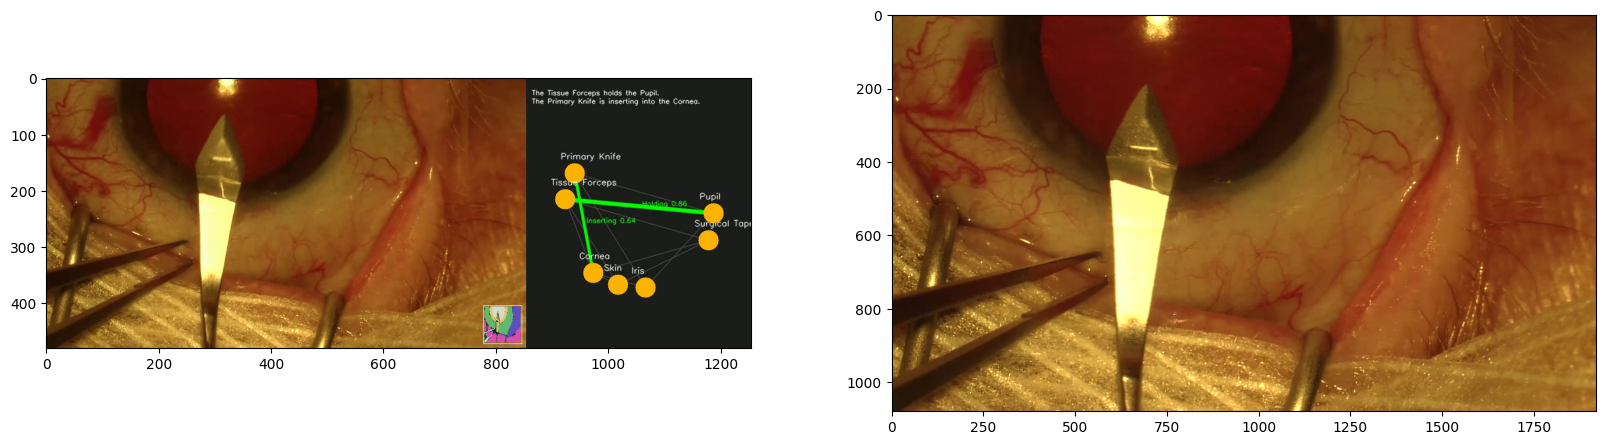

In [10]:
_min = 0
sec = 23
offset = +30
idx = int(FPS * 60 * _min + FPS * sec +offset)
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(scene_graph_video.get_data(idx - 25))
plt.subplot(1, 2, 2)
plt.imshow(video.get_data(idx))
#for relation in scene_graphs['annotations'][str(idx // 25)]:
#    print(scene_graphs['categories']['triplet'][str(relation[0])])
plt.savefig(f"qualitative/cataract_{idx}.pdf")

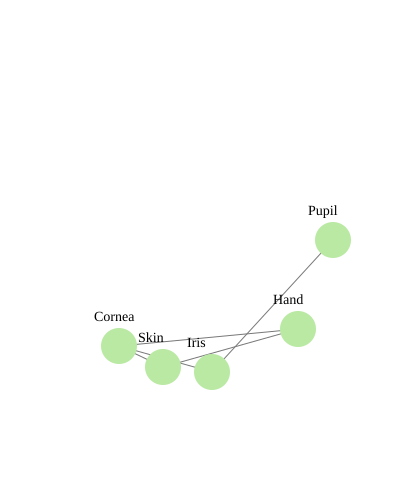

In [6]:
vis_this_pred = deepcopy(prediction[str(idx)])
vis_this_pred["semantic_relations"] = [[(rel[0]), rel[1], (rel[2]), rel[3]] for rel in vis_this_pred["semantic_relations"] if rel[3] > 0.5]
vis_this_pred["geometric_relations"] = [[(rel[0]), (rel[1])] for rel in vis_this_pred["geometric_relations"]]
svg_str = sg_visualizer.render_graph_svg(vis_this_pred["semantic_relations"], vis_this_pred["geometric_relations"])
display(SVG(svg_str))

In [ ]:
#with open(f"qualitative/cholec_{idx}_pred.svg", "w") as f:
#    f.write(svg_str)